In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.spatial.distance import pdist
from shared.rlhc import random_latin_hypercube

## 1.4 Designing a Sampling Plan
#### 1.4.1 Stratification

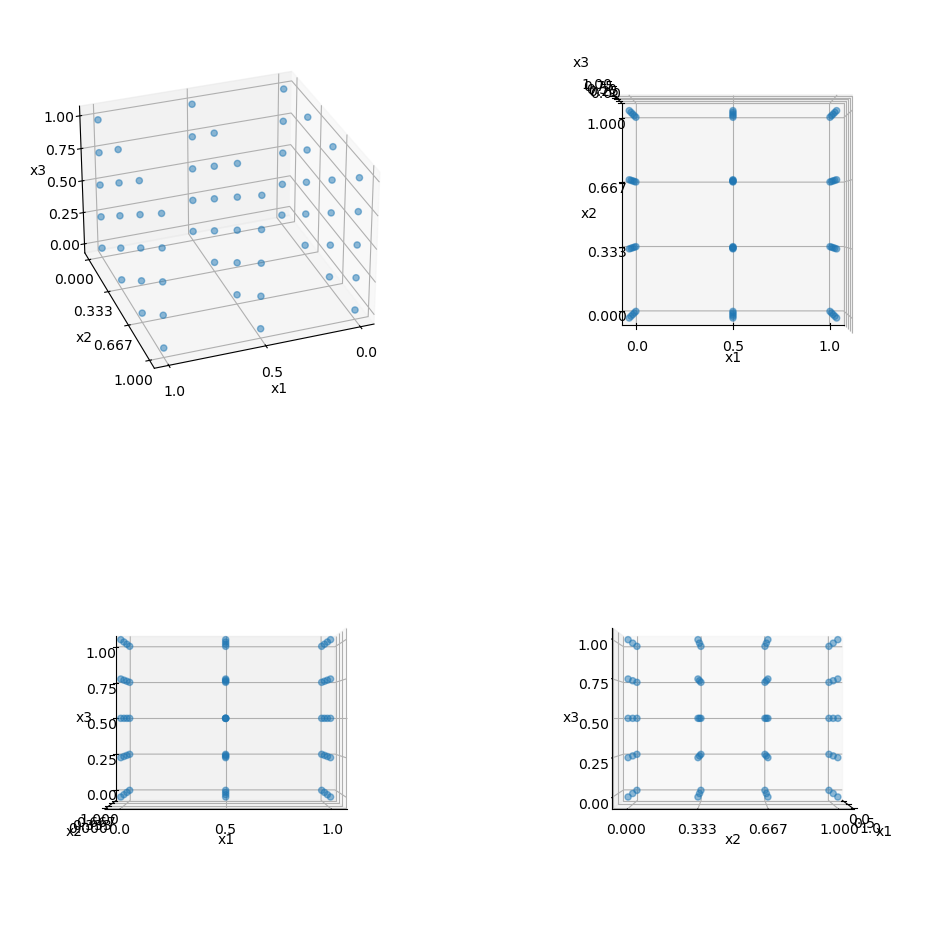

In [ ]:
def full_factorial(q: list) -> None:

    if min(q) < 2:
        raise Exception("You must have at least two points per dimension")

    x1 = np.linspace(0,1,q[0])
    x2 = np.linspace(0,1,q[1])
    x3 = np.linspace(0,1,q[2])
    
    X1, X2, X3 = np.meshgrid(x1, x2, x3, indexing='ij')

    fig = plt.figure(figsize=(12, 12))

    elevations = [None, 90, 0, 0]
    azimuths   = [70, -90, -90, 0]

    for i, elev, azim in zip(range(1,5), elevations, azimuths):
        ax = fig.add_subplot(2,2,i, projection='3d')

        ax.xaxis.set_major_locator(MultipleLocator(1/(q[0]-1)))
        ax.xaxis.set_minor_locator(MultipleLocator(1/(q[0]-1)))

        ax.yaxis.set_major_locator(MultipleLocator(1/(q[1]-1)))
        ax.yaxis.set_minor_locator(MultipleLocator(1/(q[1]-1)))
        
        ax.zaxis.set_major_locator(MultipleLocator(1/(q[2]-1)))
        ax.zaxis.set_minor_locator(MultipleLocator(1/(q[2]-1)))
        
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_zlabel('x3')
        ax.scatter(X1, X2, X3, alpha=0.5)

        ax.view_init(elev=elev, azim=azim)
        ax.set_box_aspect(None, zoom=0.85)

    plt.show()

full_factorial([3,4,5])

Translated code from book. Chose to just use np meshgrids to avoid some loops

#### 1.4.2 Latin Squares and Random Latin Hypercubes

In [ ]:
def plot_rlh(X:np.ndarray) -> None:

    X1 = X[:,0]
    X2 = X[:,1]
    X3 = X[:,2]

    fig = plt.figure(figsize=(12, 12))

    elevations = [None, 90, 0, 0]
    azimuths   = [70, -90, -90, 0]

    for i, elev, azim in zip(range(1,5), elevations, azimuths):
        ax = fig.add_subplot(2,2,i, projection='3d')

        ax.xaxis.set_minor_locator(MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(MultipleLocator(0.1))
        ax.zaxis.set_minor_locator(MultipleLocator(0.1))

        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_zlabel('x3')
        
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])

        ax.scatter(X1, X2, X3, alpha=0.5)

        ax.view_init(elev=elev, azim=azim)
        ax.set_box_aspect(None, zoom=0.85)
    
    plt.show()

In [2]:
X = random_latin_hypercube(25,3)
plot_rlh(X,25)

[[20. 14. 14.]
 [22.  7. 17.]
 [24. 13.  8.]
 [15. 21. 12.]
 [23.  9. 15.]
 [ 5.  0. 20.]
 [17. 18. 18.]
 [21.  6.  4.]
 [ 9.  1. 22.]
 [16. 12. 13.]
 [ 7. 10.  3.]
 [19.  3.  2.]
 [12. 22. 16.]
 [18.  8. 23.]
 [11. 15. 10.]
 [10. 16.  5.]
 [ 3. 20. 24.]
 [ 1. 17.  9.]
 [ 6. 11. 11.]
 [ 4.  4.  1.]
 [ 0. 19. 19.]
 [ 8. 23.  0.]
 [14.  2.  6.]
 [13. 24. 21.]
 [ 2.  5.  7.]]


NameError: name 'plot_rlh' is not defined

Although this ensures projection onto the axes does not result in multiple points overlapping, it does not result in maximal space-filling. This is where Johnson maximin metric and Morris and Mitchel's 'tie-breaker' strategies come together to produce the space filling latin hypercube method.

- **Maximin**: We call $X$ a maximin plan among all plans if it maximizes $d_1$ and, among all plans for which this is true minimizes $j_1$ (where $d_1$ is distance between possible pairs of points sorted in ascending order, and $j_1$ is the number of pairs of points in $X$ separated by $d_1$)

We want to maximize the smallest distance between pairs, and minimize the number of pairs that share this smallest distance.

This will sometimes result in a tie, so Morris and Mitchell's tie breaker method comes into play. Basically, its the same as Maximin but instead of stopping at maximizing $d_1$ and minimizing $j_1$, it maximizes $d_1 \ldots d_m$ and minimizes $j_1 \ldots j_m$.

$$d_p (x^{(i_1)}, x^{(i_2)}) = (\sum_{j=1}^{k}|x_j^{(i_1)} - x_j^{(i_2)}|)^{\frac{1}{p}}$$


/tmp/ipykernel_42850/179945681.py:20: RuntimeWarning: overflow encountered in power
  return sum(((J/(d**q))**(1/q)))


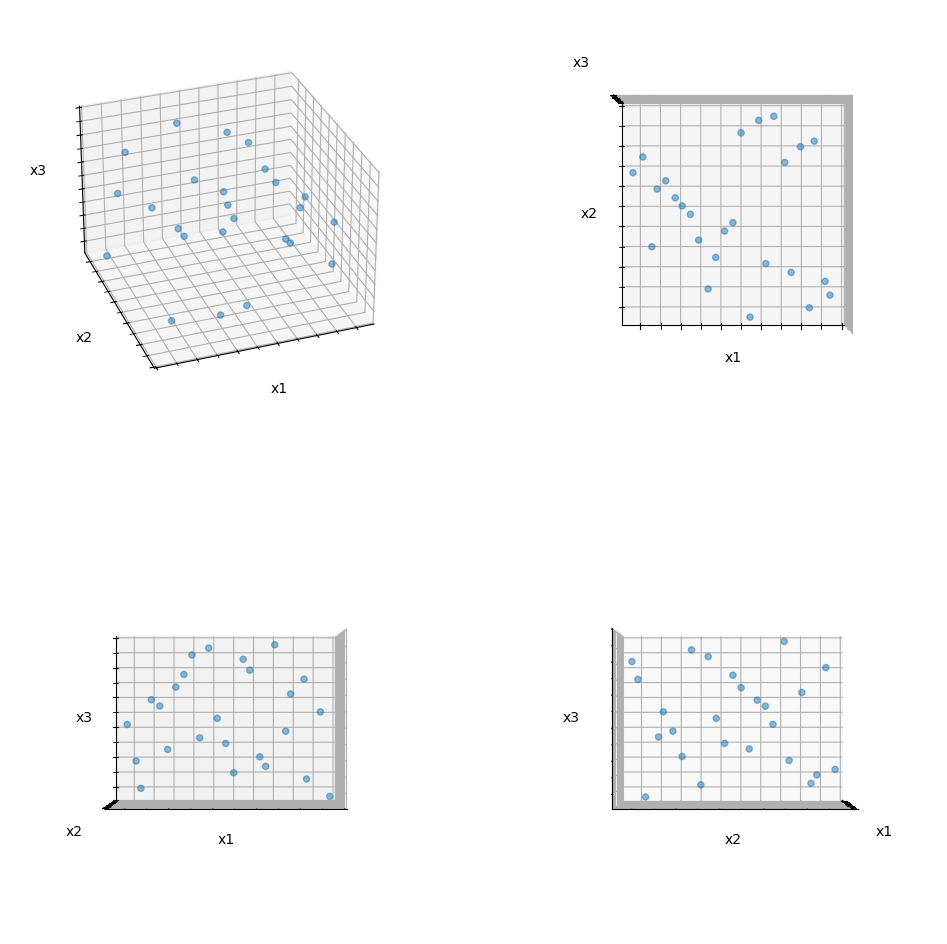

In [ ]:
def dist(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # # My original approach:
    # distances = []
    # for i in range(len(X)-1):
    #     for j in range(1,len(X)):
    #         distances.append(np.linalg.norm(X[i,:] - X[j,:]))
    
    # # round because normalized to [0,1]
    # return np.unique(distances, return_counts=True) # returns distinct_d, J

    # claude suggested using pdists from scipy instead:
    sq_dists = pdist(X, metric='sqeuclidean')
    return np.unique(sq_dists, return_counts=True) # returns distinct_d, J


def mm_phiq(X,q=2):
    d,J = dist(X)

    # morris mitchell sampling plan quality criterion
    return sum(((J/(d**q))**(1/q)))


def perturb(X: np.ndarray, pert_n=1):
    n = X.shape[0]
    k = X.shape[1]

    for _ in range(1,pert_n):
        col = int(np.floor(np.random.random()*k))
        
        el1 = el2 = 1
        while el1==el2:
            el1 = int(np.floor(np.random.random()*n))
            el2 = int(np.floor(np.random.random()*n))

        buffer = X[el1,col]
        X[el1,col] = X[el2,col]
        X[el2,col] = buffer

    return X


def best_lhc_by_q(X_start, pop, iter, q):
    X_best = X_start; 
    phi_best = mm_phiq(X_start, q)

    n = X_best.shape[0]

    leveloff = math.floor(0.85*iter)
    for it in range(1,iter):
        if it < leveloff:
            mutations = round(1+(0.5*n-1)*(leveloff-it)/(leveloff-1))
        else:
            mutations = 1
    
        X_improved   = X_best
        phi_improved = phi_best
        
        for _ in range(1,pop):
            X_try = perturb(X_best, mutations)
            phi_try = mm_phiq(X_try, q)
            
            if phi_try < phi_improved:
                X_improved = X_try
                phi_improved = phi_try
        
        if phi_improved < phi_best:
            X_best = X_improved
            phi_best = phi_improved

    return X_best, phi_best


def space_filling_latin_hypercube(
        n:int,
        k:int,
        pop:int,
        iter:int
    ) -> None:
    X_start = random_latin_hypercube(n,k) # get sampling plan

    qs = [1,2,5,10,20,50,100]

    X_tracker = {
        "q": "",
        "phi": math.inf,
        "X": ""
    }

    for q in qs:
        X_best, phi_best = best_lhc_by_q(X_start, pop, iter, q)

        if phi_best < X_tracker["phi"]:
            X_tracker["q"]   = q
            X_tracker["phi"] = phi_best
            X_tracker["X"]   = X_best
    
    plot_rlh(X_tracker["X"],n)


space_filling_latin_hypercube(25,3,25,25)